In [1]:
!uv add pandas numpy

Resolved 15 packages in 38ms
Checked 14 packages in 9ms


In [2]:
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

In [6]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
col_with_high_miss = df.isnull().sum().sort_values(ascending=False)

In [9]:
col_with_high_miss = col_with_high_miss[col_with_high_miss>0]

In [10]:
col_with_high_miss

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [11]:
col_with_high_miss = (df.isnull().mean().sort_values(ascending=False))*100

In [12]:
col_with_high_miss = col_with_high_miss[col_with_high_miss>65].sort_values(ascending=False)

In [13]:
col_with_high_miss = col_with_high_miss.index.tolist()


In [14]:
col_with_high_miss


['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [15]:
df1 = df.drop(columns=col_with_high_miss)

In [16]:
df.shape

(1460, 81)

In [17]:
df1.shape

(1460, 77)

In [18]:
# Drop irrelevant columns

df1 = df1.drop(columns=['Id'], errors='ignore')

In [19]:
low_cor_col = df.select_dtypes(include=[np.number]).corr()["SalePrice"].abs()

In [20]:
thershold = 0.1
low_cor_col = low_cor_col[low_cor_col<thershold].index.tolist()

In [21]:
len(low_cor_col)

11

In [22]:
df1 = df1.drop(columns=low_cor_col,errors = "ignore")

In [23]:
df1.shape

(1460, 66)

In [24]:
corr_matriz = df1.select_dtypes(include=[np.number]).corr().abs()
corr_matriz

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,1.000000,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,0.426095,1.000000,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,0.251646,0.105806,1.000000,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,0.123349,0.014228,0.572323,1.000000,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.592855,1.000000,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,0.193458,0.104160,0.411876,0.315707,0.179618,1.000000,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,0.249503,0.128451,0.264736,1.000000,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,0.132644,0.002618,0.308159,0.149040,0.181133,0.114442,0.495251,1.000000,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,0.392075,0.260833,0.537808,0.391452,0.291066,0.363936,0.522396,0.415360,1.000000,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,0.457181,0.299475,0.476224,0.281986,0.240379,0.344501,0.445863,0.317987,0.819530,1.000000,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [25]:
np.triu(np.ones(corr_matriz.shape),k=1)

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],


In [26]:
upper = corr_matriz.where(np.triu(np.ones(corr_matriz.shape),k=1).astype(bool))

In [27]:
upper.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [28]:
upper

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,NaN,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,NaN,NaN,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,NaN,NaN,NaN,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,NaN,NaN,NaN,NaN,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,NaN,NaN,NaN,NaN,NaN,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,NaN,NaN,NaN,NaN,NaN,NaN,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [29]:
redunted_col = [column for column in upper.columns if any(upper[column]>0.8)]

redunted_col

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']

In [30]:
df2 = df1.drop(columns=redunted_col,errors="ignore")

In [31]:
df2.shape

(1460, 62)

In [32]:
missing_col = df2.isnull().sum().sort_values(ascending=False)
missing_col = missing_col[missing_col>0]
missing_col

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageQual       81
GarageFinish     81
GarageType       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtFinType1     37
BsmtQual         37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64

In [33]:
# !uv add seaborn

In [34]:
# !uv add matplotlib

In [35]:
import matplotlib.pyplot as plt

In [36]:
import seaborn as sns

In [37]:
print(missing_col)

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageQual       81
GarageFinish     81
GarageType       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtFinType1     37
BsmtQual         37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64


In [38]:
missing_col_list = missing_col.index.tolist()
missing_col_list

['MasVnrType',
 'FireplaceQu',
 'LotFrontage',
 'GarageQual',
 'GarageFinish',
 'GarageType',
 'GarageCond',
 'BsmtExposure',
 'BsmtFinType2',
 'BsmtFinType1',
 'BsmtQual',
 'BsmtCond',
 'MasVnrArea',
 'Electrical']

In [39]:
df2[['MasVnrType',
 'FireplaceQu',
 'LotFrontage',
 'GarageQual',
 'GarageFinish',
 'GarageType',
 'GarageCond',
 'BsmtExposure',
 'BsmtFinType2',
 'BsmtFinType1',
 'BsmtQual',
 'BsmtCond',
 'MasVnrArea',
 'Electrical']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MasVnrType    588 non-null    str    
 1   FireplaceQu   770 non-null    str    
 2   LotFrontage   1201 non-null   float64
 3   GarageQual    1379 non-null   str    
 4   GarageFinish  1379 non-null   str    
 5   GarageType    1379 non-null   str    
 6   GarageCond    1379 non-null   str    
 7   BsmtExposure  1422 non-null   str    
 8   BsmtFinType2  1422 non-null   str    
 9   BsmtFinType1  1423 non-null   str    
 10  BsmtQual      1423 non-null   str    
 11  BsmtCond      1423 non-null   str    
 12  MasVnrArea    1452 non-null   float64
 13  Electrical    1459 non-null   str    
dtypes: float64(2), str(12)
memory usage: 159.8 KB


In [40]:
print(df2["MasVnrType"].dtype)


str


In [41]:
df2["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [42]:
df3 = df2.copy()

In [43]:
def mode_impute(df, mis_col):

    for col in mis_col:

        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f"{col} → mode imputed")

        else:
            print(f"{col} → numerical, skipped")

In [44]:
def mode_impute(df, mis_col):

    for col in mis_col:

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
            print(f"{col} → median imputed")

        else:
            print(f"{col} → string, skipped")

In [45]:
mode_impute(df3,missing_col_list)

MasVnrType → string, skipped
FireplaceQu → string, skipped
LotFrontage → median imputed
GarageQual → string, skipped
GarageFinish → string, skipped
GarageType → string, skipped
GarageCond → string, skipped
BsmtExposure → string, skipped
BsmtFinType2 → string, skipped
BsmtFinType1 → string, skipped
BsmtQual → string, skipped
BsmtCond → string, skipped
MasVnrArea → median imputed
Electrical → string, skipped


In [46]:
df3[['MasVnrType',
 'FireplaceQu',
 'LotFrontage',
 'GarageQual',
 'GarageFinish',
 'GarageType',
 'GarageCond',
 'BsmtExposure',
 'BsmtFinType2',
 'BsmtFinType1',
 'BsmtQual',
 'BsmtCond',
 'MasVnrArea',
 'Electrical']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MasVnrType    588 non-null    str    
 1   FireplaceQu   770 non-null    str    
 2   LotFrontage   1460 non-null   float64
 3   GarageQual    1379 non-null   str    
 4   GarageFinish  1379 non-null   str    
 5   GarageType    1379 non-null   str    
 6   GarageCond    1379 non-null   str    
 7   BsmtExposure  1422 non-null   str    
 8   BsmtFinType2  1422 non-null   str    
 9   BsmtFinType1  1423 non-null   str    
 10  BsmtQual      1423 non-null   str    
 11  BsmtCond      1423 non-null   str    
 12  MasVnrArea    1460 non-null   float64
 13  Electrical    1459 non-null   str    
dtypes: float64(2), str(12)
memory usage: 159.8 KB


In [47]:
df3["SalePrice"].value_counts()

SalePrice
140000    20
135000    17
145000    14
155000    14
110000    13
          ..
92000      1
287090     1
266500     1
142125     1
147500     1
Name: count, Length: 663, dtype: int64

In [48]:
print(df3["LotFrontage"].corr(df3["SalePrice"]))

0.33477085313975996


In [ ]:
def LotFrontage_detect(df, col, target_col):
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    print("Data type:", df[col].dtype)
    print("Data type:", df[col].value_counts)

    sns.boxplot(data=df, x=col, ax=ax[0])
    ax[0].set_title("Box Plot")

    sns.scatterplot(data=df, x=col, y=target_col, ax=ax[1])
    ax[1].set_title("Scatter Plot")

    sns.histplot(data=df, x=col, kde=True, ax=ax[2])
    ax[2].set_title("Histogram")

    plt.tight_layout()
    plt.show()

    return df[col].corr(df[target_col])

Data type: float64
Data type: <bound method IndexOpsMixin.value_counts of 0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64>


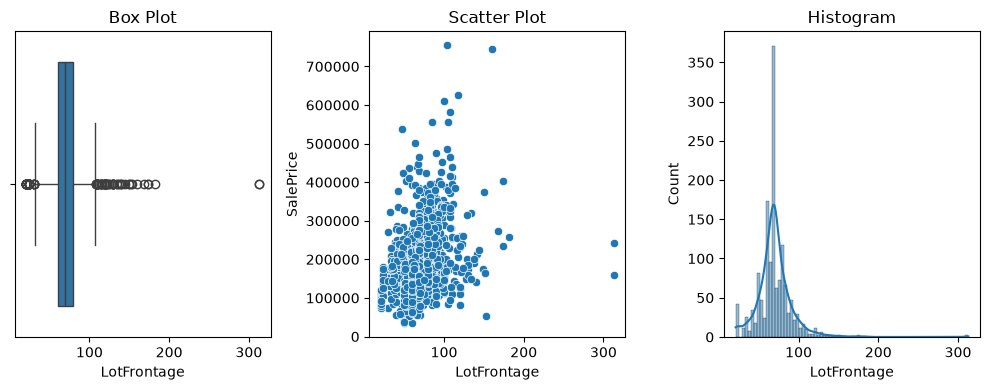

np.float64(0.33477085313975996)

In [ ]:
LotFrontage_detect(df3, 'LotFrontage', "SalePrice")

## Handle oulier

In [51]:
df4= df3.copy()

In [52]:
numerical_col = []
for col in df4.columns:
    if pd.api.types.is_numeric_dtype(df4[col]):
        numerical_col.append(col)

In [53]:
df4.shape

(1460, 62)

In [54]:
len(numerical_col)

23

In [55]:
df4.dtypes.value_counts()

str        39
int64      21
float64     2
Name: count, dtype: int64

In [56]:
numerical_col

['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageCars',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'SalePrice']

In [126]:
def LotFrontage_detect_fun(df, independent_col, target_col):
    for col in independent_col:
        fig, ax = plt.subplots(1, 3, figsize=(10, 4))

        print("Data type:", df[col].dtype)
        print("Data type:", df[col].value_counts)

        sns.boxplot(data=df, x=col, ax=ax[0])
        ax[0].set_title("Box Plot")

        sns.scatterplot(data=df, x=col, y=target_col, ax=ax[1])
        ax[1].set_title("Scatter Plot")

        sns.histplot(data=df, x=col, kde=True, ax=ax[2])
        ax[2].set_title("Histogram")

        plt.tight_layout()
        plt.show()

    return df[col].corr(df[target_col])

Data type: float64
Data type: <bound method IndexOpsMixin.value_counts of 0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64>


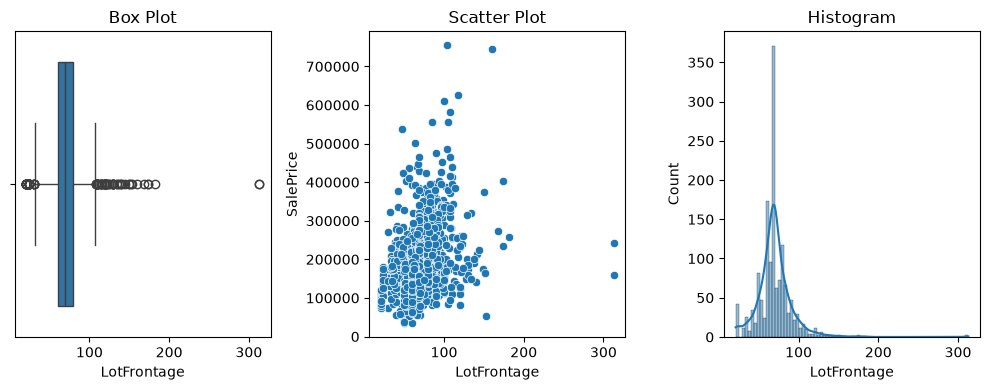

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0        8450
1        9600
2       11250
3        9550
4       14260
        ...  
1455     7917
1456    13175
1457     9042
1458     9717
1459     9937
Name: LotArea, Length: 1460, dtype: int64>


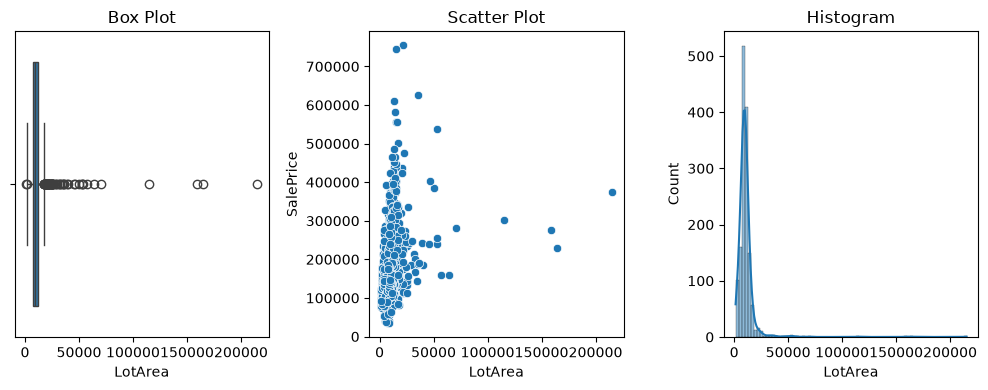

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64>


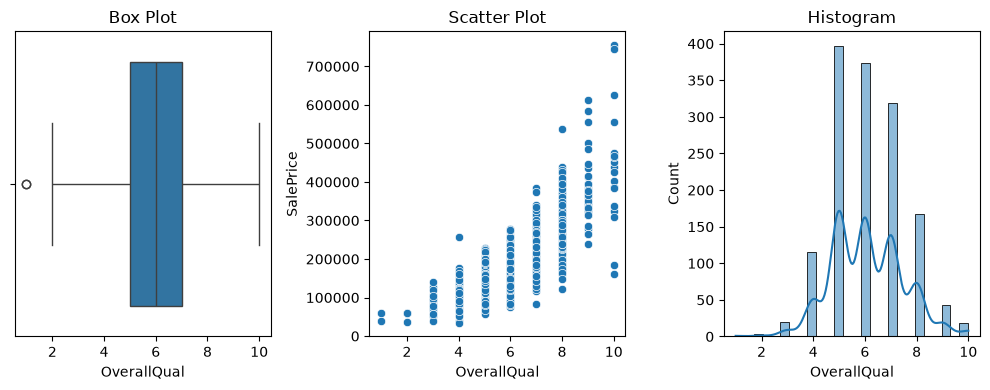

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       2003
1       1976
2       2001
3       1915
4       2000
        ... 
1455    1999
1456    1978
1457    1941
1458    1950
1459    1965
Name: YearBuilt, Length: 1460, dtype: int64>


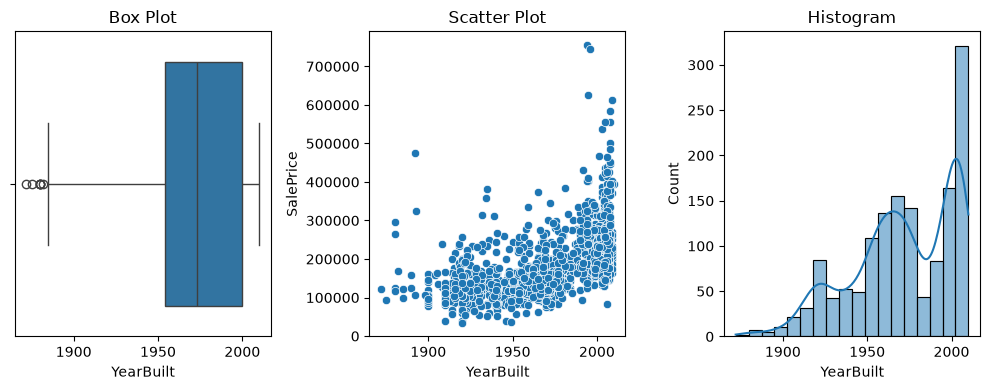

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       2003
1       1976
2       2002
3       1970
4       2000
        ... 
1455    2000
1456    1988
1457    2006
1458    1996
1459    1965
Name: YearRemodAdd, Length: 1460, dtype: int64>


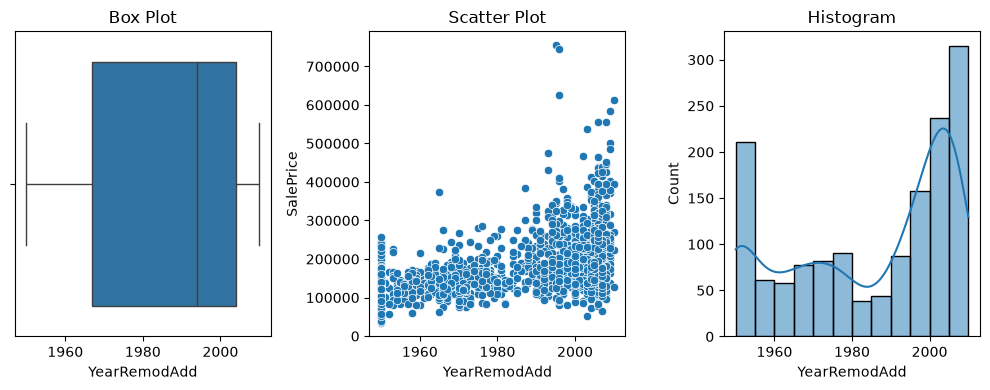

Data type: float64
Data type: <bound method IndexOpsMixin.value_counts of 0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64>


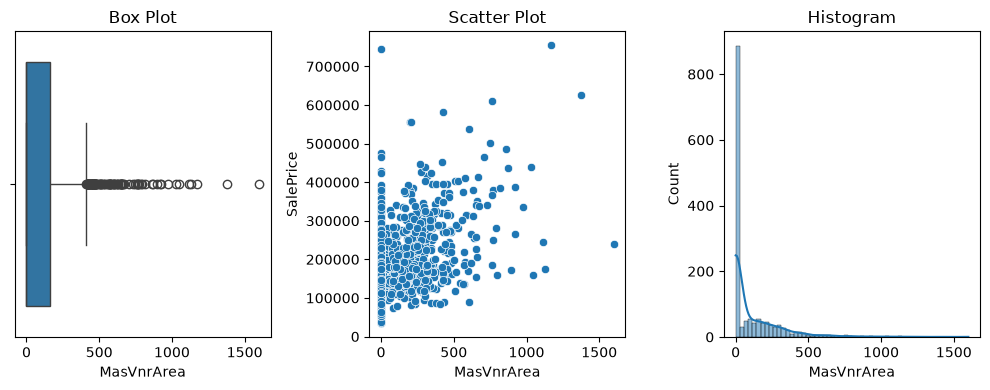

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       706
1       978
2       486
3       216
4       655
       ... 
1455      0
1456    790
1457    275
1458     49
1459    830
Name: BsmtFinSF1, Length: 1460, dtype: int64>


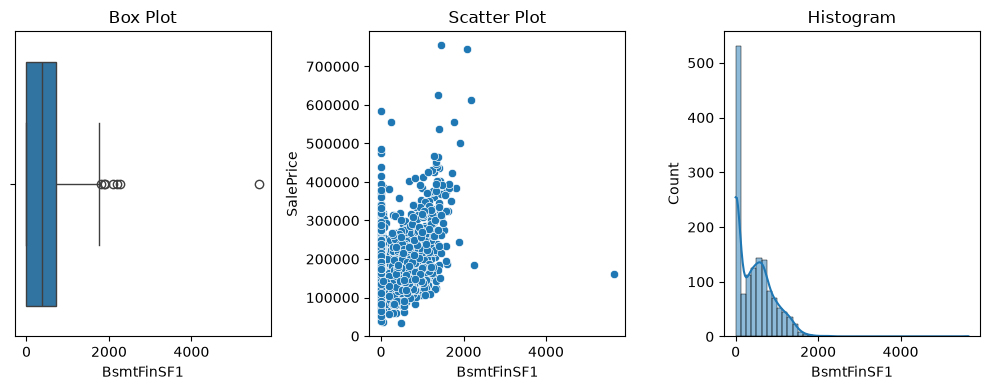

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       150
1       284
2       434
3       540
4       490
       ... 
1455    953
1456    589
1457    877
1458      0
1459    136
Name: BsmtUnfSF, Length: 1460, dtype: int64>


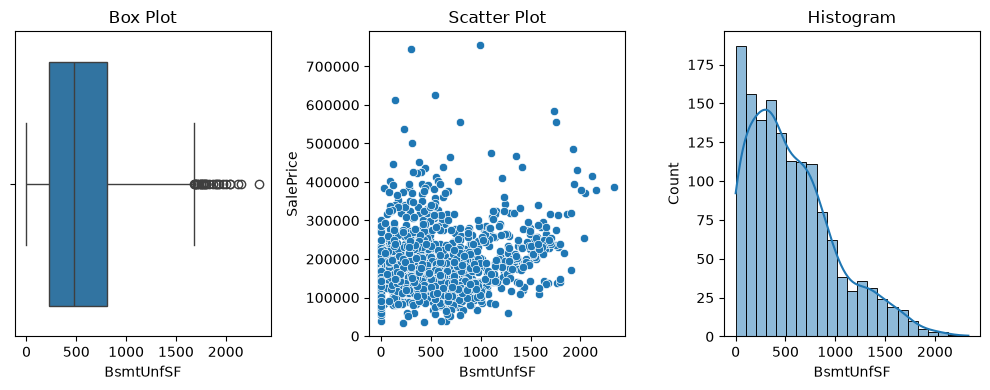

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0        856
1       1262
2        920
3        756
4       1145
        ... 
1455     953
1456    1542
1457    1152
1458    1078
1459    1256
Name: TotalBsmtSF, Length: 1460, dtype: int64>


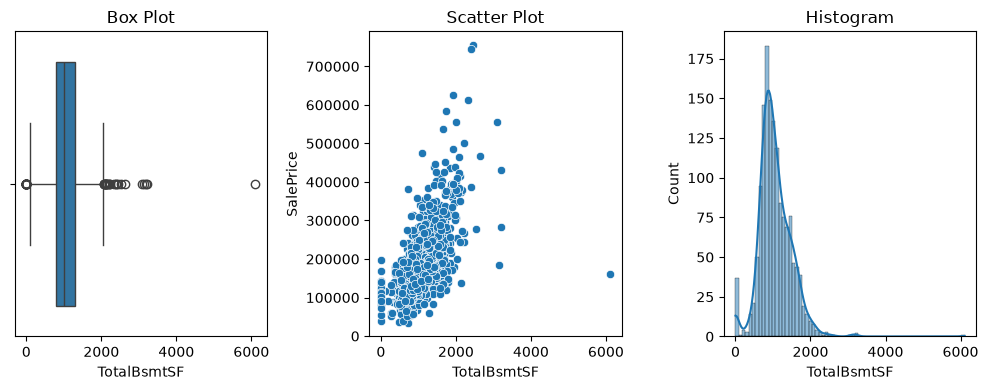

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0        854
1          0
2        866
3        756
4       1053
        ... 
1455     694
1456       0
1457    1152
1458       0
1459       0
Name: 2ndFlrSF, Length: 1460, dtype: int64>


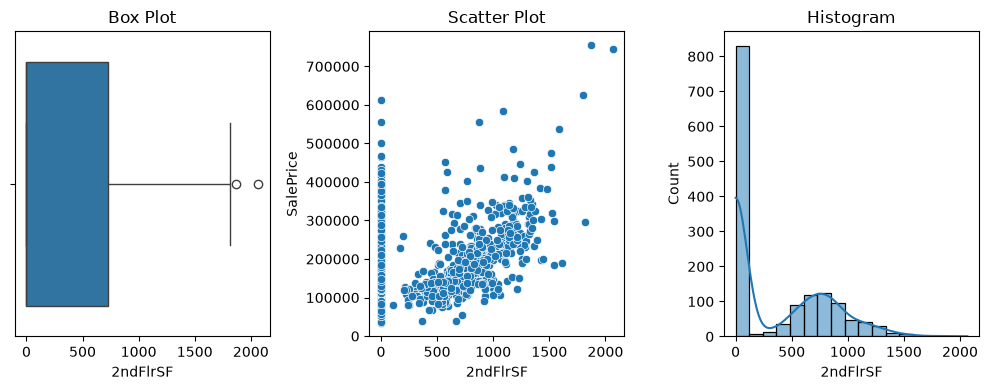

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       1710
1       1262
2       1786
3       1717
4       2198
        ... 
1455    1647
1456    2073
1457    2340
1458    1078
1459    1256
Name: GrLivArea, Length: 1460, dtype: int64>


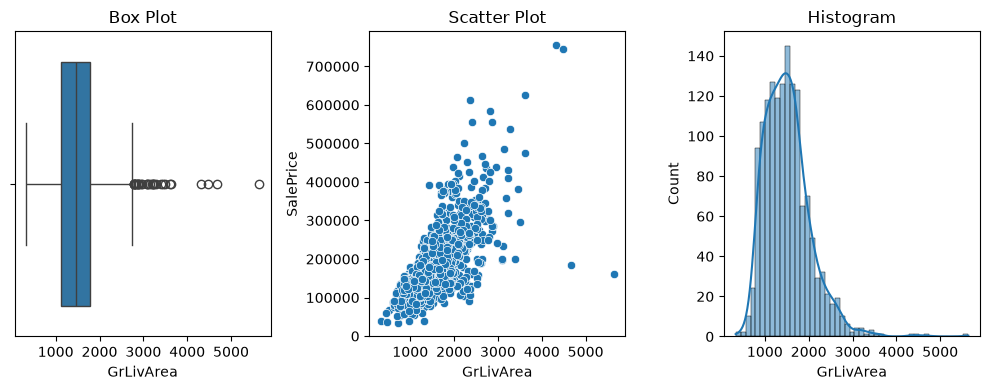

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       1
4       1
       ..
1455    0
1456    1
1457    0
1458    1
1459    1
Name: BsmtFullBath, Length: 1460, dtype: int64>


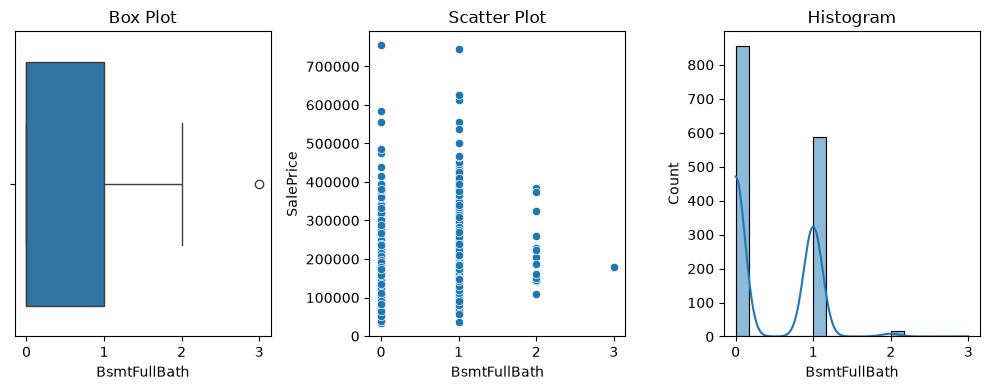

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       2
1       2
2       2
3       1
4       2
       ..
1455    2
1456    2
1457    2
1458    1
1459    1
Name: FullBath, Length: 1460, dtype: int64>


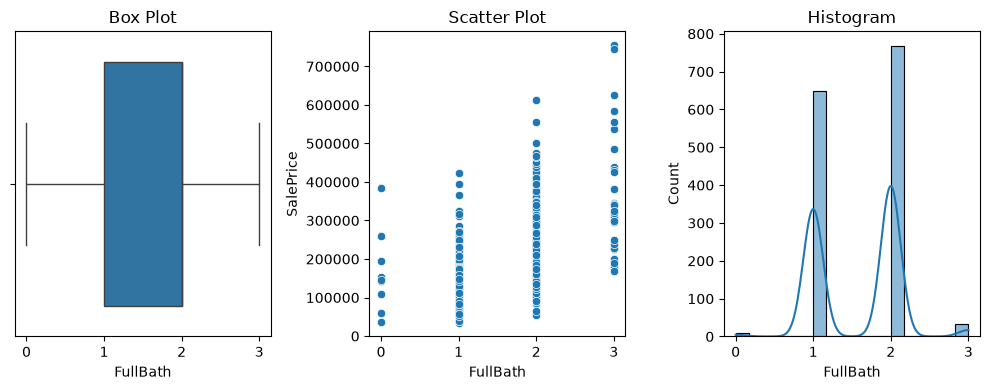

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       1
       ..
1455    1
1456    0
1457    0
1458    0
1459    1
Name: HalfBath, Length: 1460, dtype: int64>


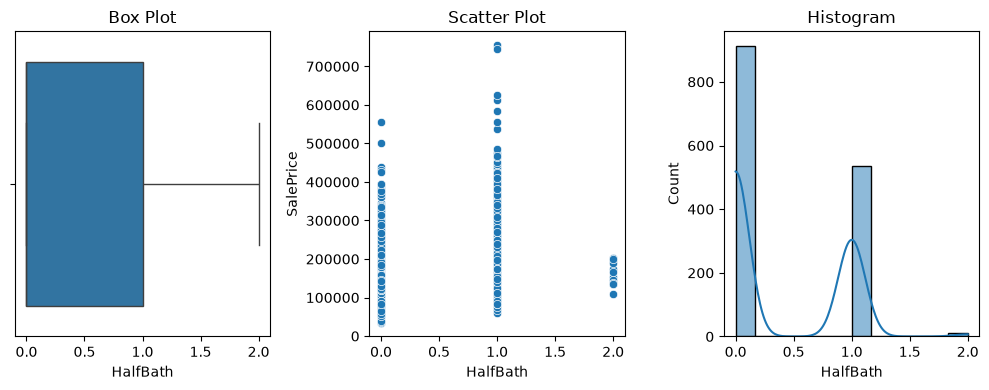

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       3
1       3
2       3
3       3
4       4
       ..
1455    3
1456    3
1457    4
1458    2
1459    3
Name: BedroomAbvGr, Length: 1460, dtype: int64>


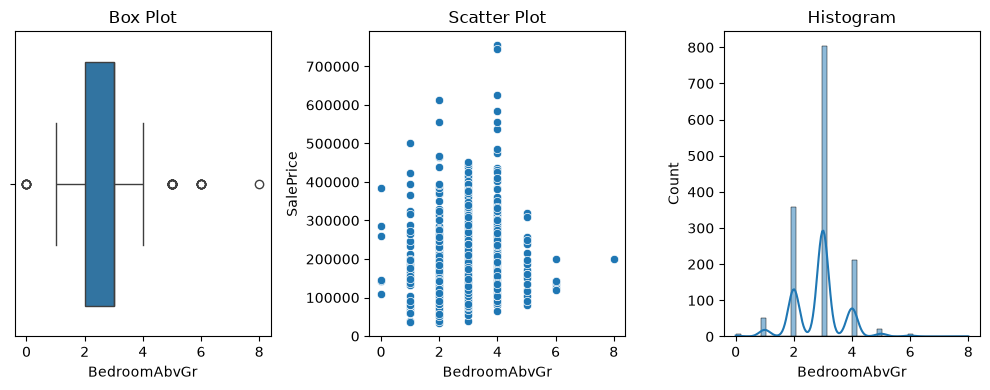

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       1
1       1
2       1
3       1
4       1
       ..
1455    1
1456    1
1457    1
1458    1
1459    1
Name: KitchenAbvGr, Length: 1460, dtype: int64>


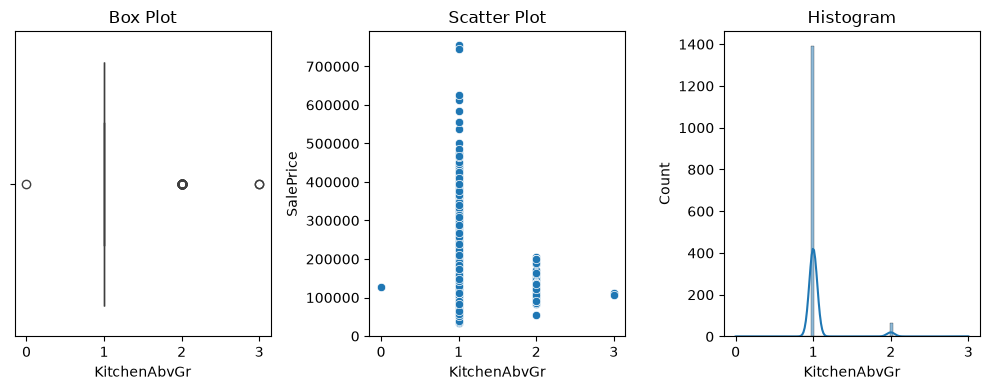

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       0
1       1
2       1
3       1
4       1
       ..
1455    1
1456    2
1457    2
1458    0
1459    0
Name: Fireplaces, Length: 1460, dtype: int64>


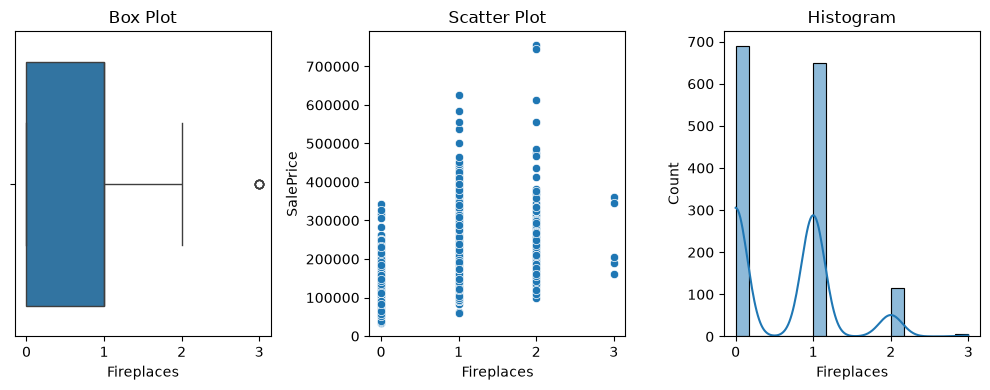

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       2
1       2
2       2
3       3
4       3
       ..
1455    2
1456    2
1457    1
1458    1
1459    1
Name: GarageCars, Length: 1460, dtype: int64>


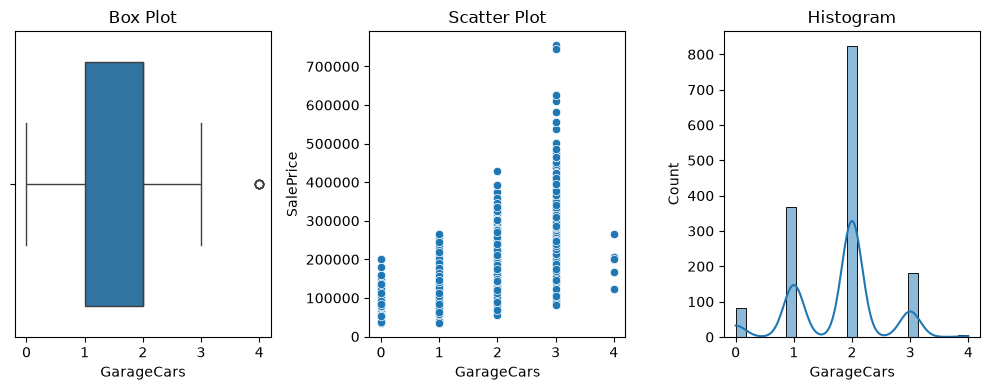

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0         0
1       298
2         0
3         0
4       192
       ... 
1455      0
1456    349
1457      0
1458    366
1459    736
Name: WoodDeckSF, Length: 1460, dtype: int64>


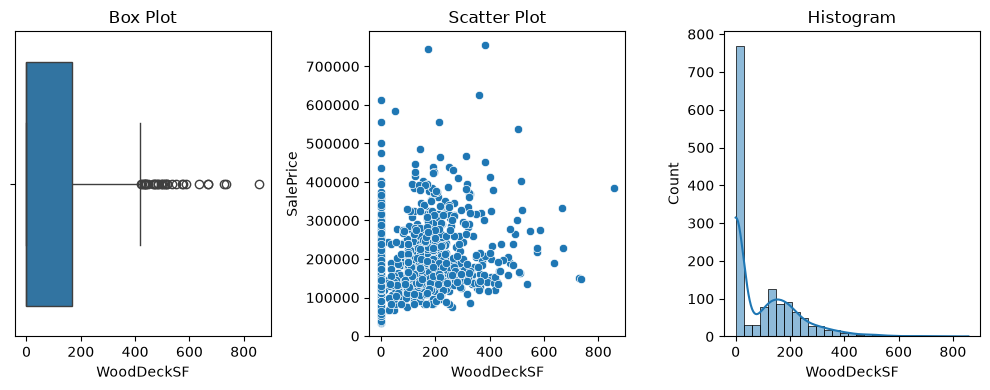

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       61
1        0
2       42
3       35
4       84
        ..
1455    40
1456     0
1457    60
1458     0
1459    68
Name: OpenPorchSF, Length: 1460, dtype: int64>


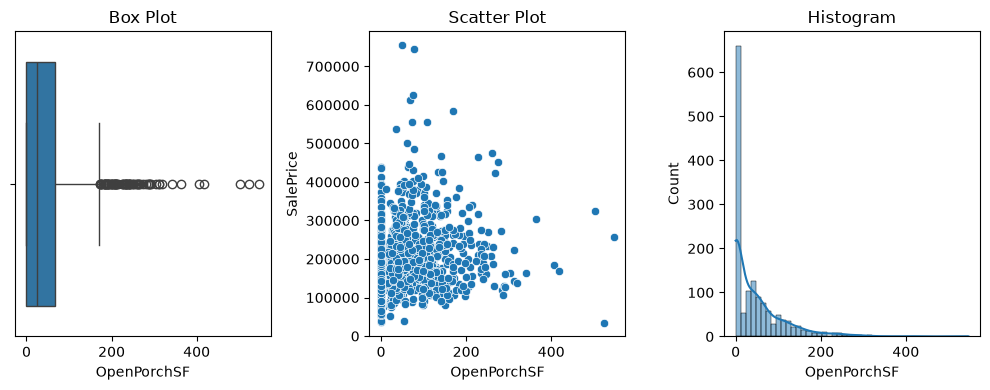

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0         0
1         0
2         0
3       272
4         0
       ... 
1455      0
1456      0
1457      0
1458    112
1459      0
Name: EnclosedPorch, Length: 1460, dtype: int64>


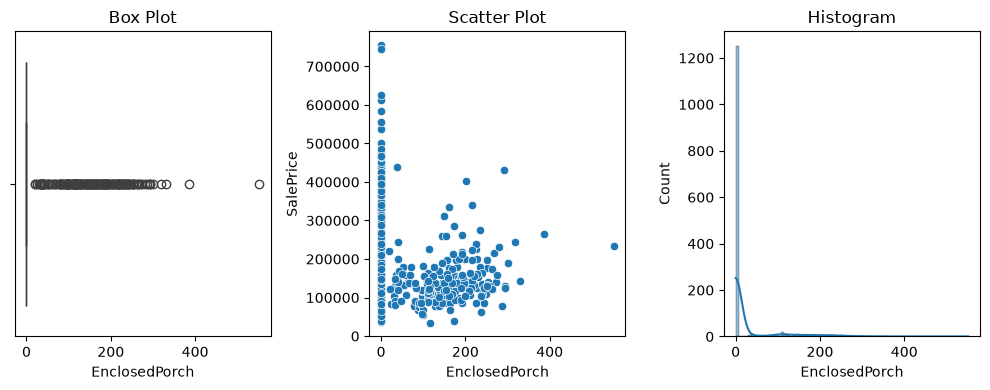

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
1455    0
1456    0
1457    0
1458    0
1459    0
Name: ScreenPorch, Length: 1460, dtype: int64>


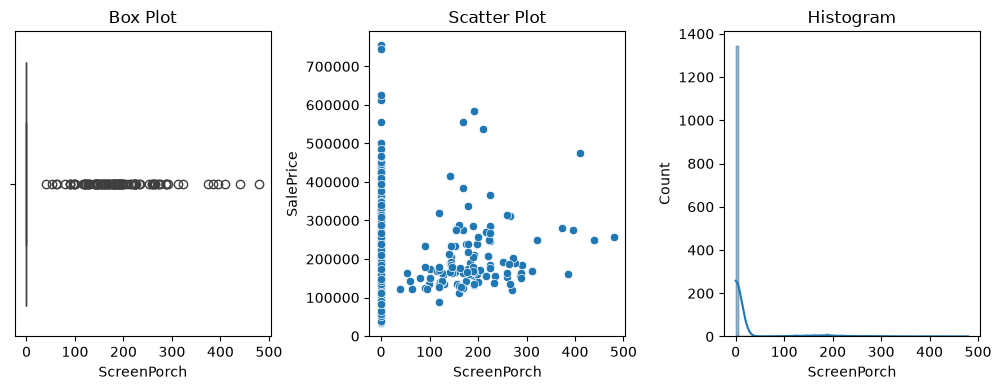

Data type: int64
Data type: <bound method IndexOpsMixin.value_counts of 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64>


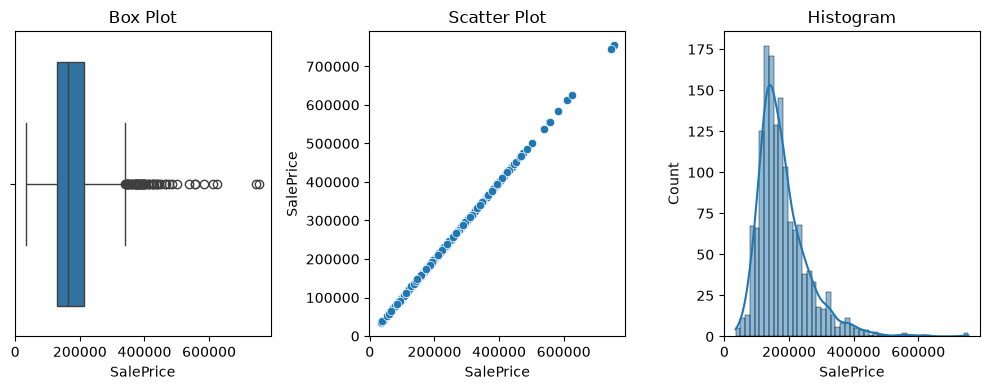

np.float64(0.9999999999999998)

In [127]:
LotFrontage_detect_fun(df4, numerical_col,"SalePrice")

In [128]:
print(df4["LotFrontage"].skew())
print(df4["TotalBsmtSF"].skew())
print(df4["SalePrice"].skew())


2.4091466665496006
1.5242545490627664
1.8828757597682129


In [60]:
# GarageCars
df3["GarageCars"].value_counts().sort_index()


GarageCars
0     81
1    369
2    824
3    181
4      5
Name: count, dtype: int64

<Axes: xlabel='GarageCars', ylabel='Count'>

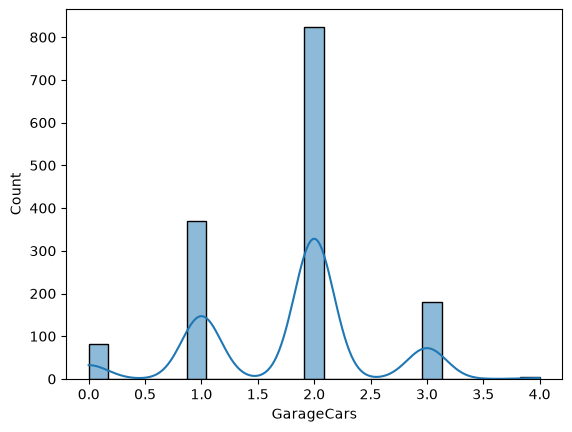

In [61]:
sns.histplot(data=df3, x="GarageCars", kde=True)

In [133]:
df4["totalBsmt"].skew()

KeyError: 'totalBsmt'

In [154]:
df3.groupby("GarageCars")["SalePrice"].agg(["count", "mean", "median"])

,count,mean,median
GarageCars,,,
0,81,103317.283951,100000.0
1,369,128116.688347,128000.0
2,824,183851.663835,177750.0
3,181,309636.121547,295000.0
4,5,192655.800000,200000.0


In [62]:
df5 = df4.copy()

In [64]:
numerical_col

['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageCars',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'SalePrice']

In [65]:
df5["LotFrontage"].skew()

np.float64(2.4091466665496006)

In [70]:
df5.loc[df5["LotFrontage"] <= 0]

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice,LotFrontage_trans


In [66]:
df5["LotFrontage_trans"] = np.log1p(df5["LotFrontage"])

In [132]:
print(df5["LotArea"].skew())


0.11007344149249713


In [125]:
df5.shape

(1209, 63)

In [ ]:
def iqr(df,col):
    sns.boxplot(data = df,x=col)
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    l = q1-1.5*IQR
    h = q3+1.5*IQR
    LotFrontage = df[(df[col] > h) | (df[col] < l)]
    LotFrontage
    print(len(LotFrontage))
    # return LotFrontage[col].tolist()
    return LotFrontage

In [ ]:
q1 = df5["TotalBsmtSF"].quantile(0.25)
q3 = df5["TotalBsmtSF"].quantile(0.75)
IQR = q3-q1
l = q1-1.5*IQR
h = q3+1.5*IQR
LotFrontage = df5[(df5["TotalBsmtSF"] > h) | (df5["TotalBsmtSF"] < l)]
df5 = df5[(df5["TotalBsmtSF"] >= l) & 
          (df5["TotalBsmtSF"] <= h)].copy()

106


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice,LotFrontage_trans
25,RL,110.0,14230,Pave,Reg,Lvl,AllPub,Corner,Gtl,NridgHt,...,TA,Y,0,56,0,0,WD,Normal,256300,4.709530
35,RL,108.0,13418,Pave,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,...,TA,Y,113,32,0,0,WD,Normal,309000,4.691348
36,RL,112.0,10859,Pave,Reg,Lvl,AllPub,Corner,Gtl,CollgCr,...,TA,Y,392,64,0,0,WD,Normal,145000,4.727388
41,RL,115.0,16905,Pave,Reg,Lvl,AllPub,Inside,Gtl,Timber,...,TA,P,0,104,0,0,WD,Normal,170000,4.753590
52,RM,110.0,8472,Grvl,IR2,Bnk,AllPub,Corner,Mod,IDOTRR,...,TA,Y,106,0,0,0,WD,Normal,110000,4.709530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,RL,129.0,16737,Pave,Reg,Lvl,AllPub,FR3,Gtl,NridgHt,...,TA,Y,194,45,0,0,WD,Normal,315000,4.867534
1361,RL,124.0,16158,Pave,IR1,Low,AllPub,Inside,Mod,StoneBr,...,TA,Y,168,36,0,0,WD,Normal,260000,4.828314
1364,FV,30.0,3180,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,TA,Y,0,166,0,0,WD,Abnorml,144152,3.433987
1378,RM,21.0,1953,Pave,Reg,Lvl,AllPub,Inside,Gtl,BrDale,...,TA,Y,72,0,0,0,WD,Normal,83000,3.091042


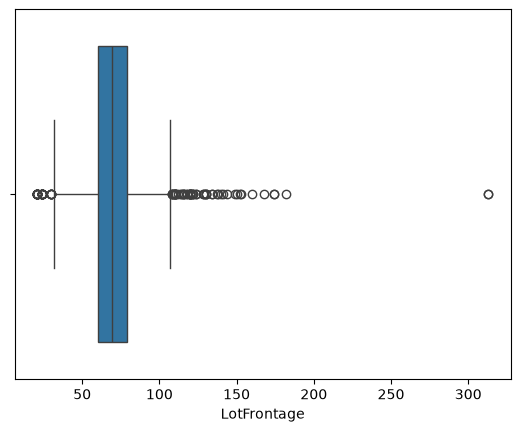

In [117]:
iqr(df5,"LotFrontage")

In [ ]:
df5["LotArea"].corr(df5["SalePrice"])

np.float64(0.2638433538714056)

69


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice,LotFrontage_trans
53,RL,68.0,50271,Pave,IR1,Low,AllPub,Inside,Gtl,Veenker,...,TA,Y,857,72,0,0,WD,Normal,385000,4.234107
66,RL,69.0,19900,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,Y,301,0,0,0,WD,Normal,180000,4.248495
113,RL,69.0,21000,Pave,Reg,Bnk,AllPub,Corner,Gtl,Crawfor,...,TA,Y,166,120,192,0,COD,Abnorml,217000,4.248495
120,RL,69.0,21453,Pave,IR1,Low,AllPub,CulDSac,Sev,ClearCr,...,TA,Y,0,130,0,0,WD,Normal,180000,4.248495
159,RL,134.0,19378,Pave,IR1,HLS,AllPub,Corner,Gtl,Gilbert,...,TA,Y,239,132,0,0,New,Partial,320000,4.905275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1396,RL,69.0,57200,Pave,IR1,Bnk,AllPub,Inside,Sev,Timber,...,TA,N,0,0,50,0,WD,Normal,160000,4.248495
1409,RL,46.0,20544,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,NWAmes,...,TA,Y,364,63,0,0,WD,Normal,215000,3.850148
1423,RL,69.0,19690,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Edwards,...,Gd,Y,586,236,0,0,WD,Alloca,274970,4.248495
1430,RL,60.0,21930,Pave,IR3,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,Y,100,40,0,0,WD,Normal,192140,4.110874


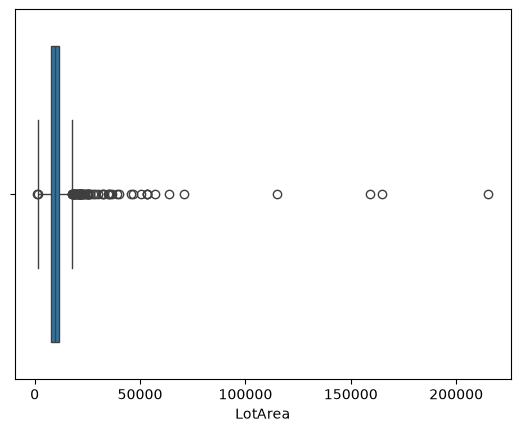

In [114]:
iqr(df5,"LotArea")

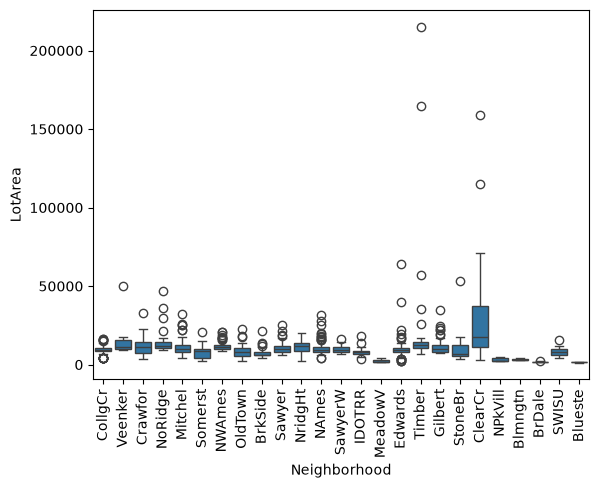

In [71]:
sns.boxplot(
    data=df3,
    x="Neighborhood",
    y="LotArea"
)

plt.xticks(rotation=90)
plt.show()

In [130]:
df5.drop(columns=["LotFrontage"])

,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice,LotFrontage_trans
0,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,TA,Y,0,61,0,0,WD,Normal,208500,4.189655
1,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Y,298,0,0,0,WD,Normal,181500,4.394449
2,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,TA,Y,0,42,0,0,WD,Normal,223500,4.234107
3,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,TA,Y,0,35,272,0,WD,Abnorml,140000,4.110874
4,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,TA,Y,192,84,0,0,WD,Normal,250000,4.442651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Y,0,40,0,0,WD,Normal,175000,4.143135
1456,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Y,349,0,0,0,WD,Normal,210000,4.454347
1457,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,TA,Y,0,60,0,0,WD,Normal,266500,4.204693
1458,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,TA,Y,366,0,112,0,WD,Normal,142125,4.234107


In [129]:
df6 = df5.copy()

In [141]:
def find_cat(df):
    l = []
    for col in df.columns:

        if pd.api.types.is_string_dtype(df[col]):
            l.append(col)
    return l 

In [146]:
len(find_cat(df6))


39

In [145]:
df["PavedDrive"].value_counts()

PavedDrive
Y    1340
N      90
P      30
Name: count, dtype: int64